In [2]:
import pandas as pd

df = pd.read_csv("../data/processed/clean_price_data.csv", parse_dates=["timestamp"])
df = df.set_index("timestamp")


In [9]:
df["hour"] = df.index.hour
df["dayofweek"] = df.index.dayofweek
df["month"] = df.index.month



In [10]:
import numpy as np

df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

In [11]:
df["lag_24"] = df["price"].shift(24)
df["lag_48"] = df["price"].shift(48)
df["lag_168"] = df["price"].shift(168)


In [12]:
df["rolling_mean_24"] = df["price"].shift(1).rolling(24).mean()
df["rolling_std_24"] = df["price"].shift(1).rolling(24).std()



In [13]:
df = df.dropna()

In [14]:
train = df[: "2025-12-31"]
test = df["2026-01-01":]


In [15]:
features = [
    "hour", "dayofweek", "month",
    "hour_sin", "hour_cos",
    "lag_24", "lag_48", "lag_168",
    "rolling_mean_24", "rolling_std_24"
]

X_train = train[features]
y_train = train["price"]

X_test = test[features]
y_test = test["price"]

In [16]:
from sklearn.linear_model import Ridge

model = Ridge()
model.fit(X_train, y_train)

pred = model.predict(X_test)

In [17]:
from sklearn.metrics import mean_absolute_error

mae_model = mean_absolute_error(y_test, pred)

# baseline (lag_24)
mae_baseline = mean_absolute_error(y_test, test["lag_24"])

print("Model MAE:", mae_model)
print("Baseline MAE (lag_24):", mae_baseline)

Model MAE: 20.087856222521786
Baseline MAE (lag_24): 22.043645833333336


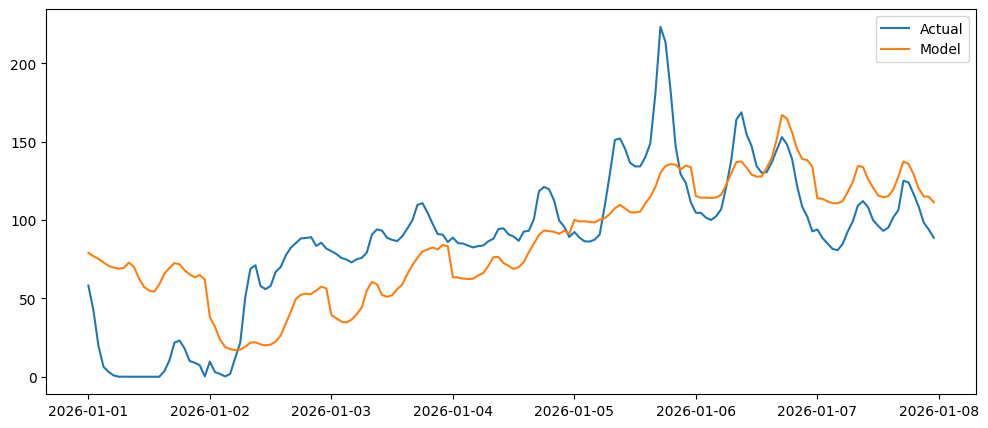

In [ ]:
import matplotlib.pyplot as plt

sample = test["2026-01-01":"2026-01-07"]

plt.figure(figsize=(12,5))
plt.plot(sample.index, sample["price"], label="Actual")
plt.plot(sample.index, pred[:len(sample)], label="Model")
#plt.plot(sample.index, sample["lag_24"], label="Baseline (Lag 24)")

plt.legend()
plt.show()